In [1]:
import matplotlib
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
import math
plots.style.use('fivethirtyeight')

# Lecture 25  Measures of Center and Spread #

## Measures of Center ##

### Average (Mean) ###

Mean is the ratio of the sum of all of the data over the number of data points. 
The value will between the lowest and highest value (but not neccessarily the middle value)

There are several ways to calculate the mean. 

In [2]:
values = make_array(2, 3, 3, 9)
values

array([2, 3, 3, 9])

In [3]:
# Brute Force Average Calculation
sum(values)/len(values)

4.25

In [4]:
# Numpy Method for Average
np.average(values)

4.25

In [5]:
# Numpy Method for Mean
np.mean(values)

4.25

In [7]:
# No code, brute force
(2 + 3 + 3 + 9)/4

4.25

In [8]:
# Fractional Proportional Calculation
2*(1/4) + 3*(2/4) + 9*(1/4)

4.25

In [9]:
# Decimal Proportional Calculation
2*0.25 + 3*0.5 + 9*0.25

4.25

In [10]:
# Still calculating means.....

values_table = Table().with_columns('value', values)
values_table

value
2
3
3
9


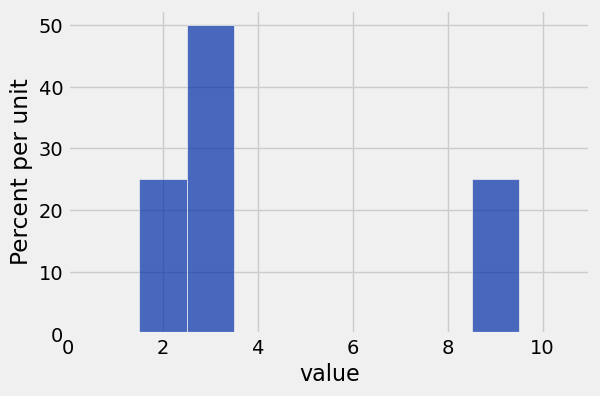

In [11]:
# Visualization of the values in the array

bins_for_display = np.arange(0.5, 10.6, 1)
values_table.hist('value', bins = bins_for_display)

In [12]:
# Make array of 10 2s, 20 3s, and 10 9s

new_vals = make_array(2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
                      3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
                      9, 9, 9, 9, 9, 9, 9, 9, 9, 9)

Run the code below and then compare the two histograms. Why do they look so similar?

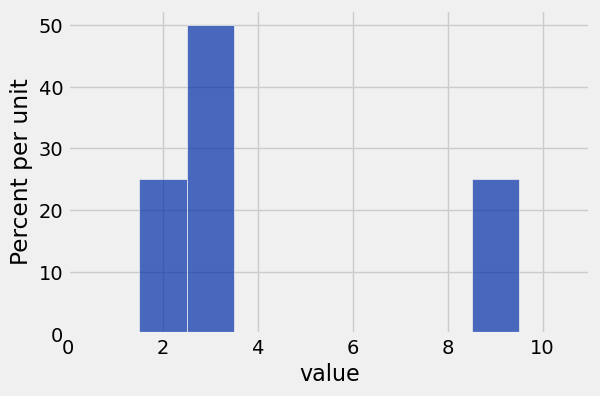

In [13]:
Table().with_column('value', new_vals).hist(bins = bins_for_display)

In [14]:
# Original Array Average
np.average(values)

4.25

In [15]:
# New Array Average
np.average(new_vals)

4.25

The average gives the value that would balance the distribution based on the wieght of each data point instead of finding the middle value (median).

* Symmetric Distributions:    the mean ? the median
* Skewed Left Distributions:  the mean ? the median
* Skewed Right Distributions: the mean ? the median

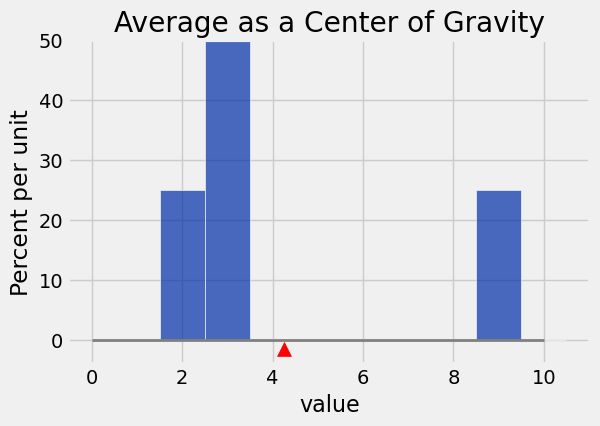

In [16]:
Table().with_column('value', new_vals).hist(bins = bins_for_display)
plots.ylim(-0.04, 0.5)
plots.plot([0, 10], [0, 0], color='grey', lw=2)
plots.scatter(4.25, -0.015, marker='^', color='red', s=100)
plots.title('Average as a Center of Gravity');

## Data Variability ##

How does the data vary from the mean?

Deviation from the mean:

* Negative values imply
* Positive values imply

### Standard Deviation ###
A standard measure to help describe the distance a value is from the mean. 

The majority of the data will lie withing 4 standard deviations of the mean. 

In [17]:
sd_table = Table().with_columns('Value', values)
sd_table

Value
2
3
3
9


In [18]:
average_value = np.mean(values)
average_value


4.25

In [19]:
# Deviation is equal to the data value minus the average alue. 

deviations = values - average_value
sd_table = sd_table.with_column('Deviation', deviations)
sd_table

Value,Deviation
2,-2.25
3,-1.25
3,-1.25
9,4.75


In [20]:
sum(deviations)

0.0

### Variance ###

The size of the deviations. This is calucated by squaring the standard deviation. 


In [21]:
sd_table = sd_table.with_column('Squared Deviation', deviations ** 2)
sd_table

Value,Deviation,Squared Deviation
2,-2.25,5.0625
3,-1.25,1.5625
3,-1.25,1.5625
9,4.75,22.5625


In [22]:
# Variance of the data:
# mean squared deviation from average

variance = np.mean(deviations ** 2)
variance

7.6875

In [23]:
# Standard Deviation (SD): 
# root mean squared deviation from average
# = square root of the variance

# Brute Force
sd = variance ** 0.5
print(f"Brute: {sd}")

# Math Module
sd = math.sqrt(variance)
print(f" Math: {sd}")

# Numpy Module
sd = np.sqrt(variance)
print(f"Numpy: {sd}")

Brute: 2.7726341266023544
 Math: 2.7726341266023544
Numpy: 2.7726341266023544


In [24]:
# Numpy Standard Deviation Method
np.std(values)

2.7726341266023544

### Chebyshev's Bounds ###

No matter what the shape of the distribution,
the bulk of the data are in the range “average ± a few SDs”

How to calculate Chebyshev's Bounds


In [25]:
births = Table.read_table('baby.csv').drop('Maternal Smoker')
births.num_rows

1174

In [26]:
births.labels

('Birth Weight',
 'Gestational Days',
 'Maternal Age',
 'Maternal Height',
 'Maternal Pregnancy Weight')

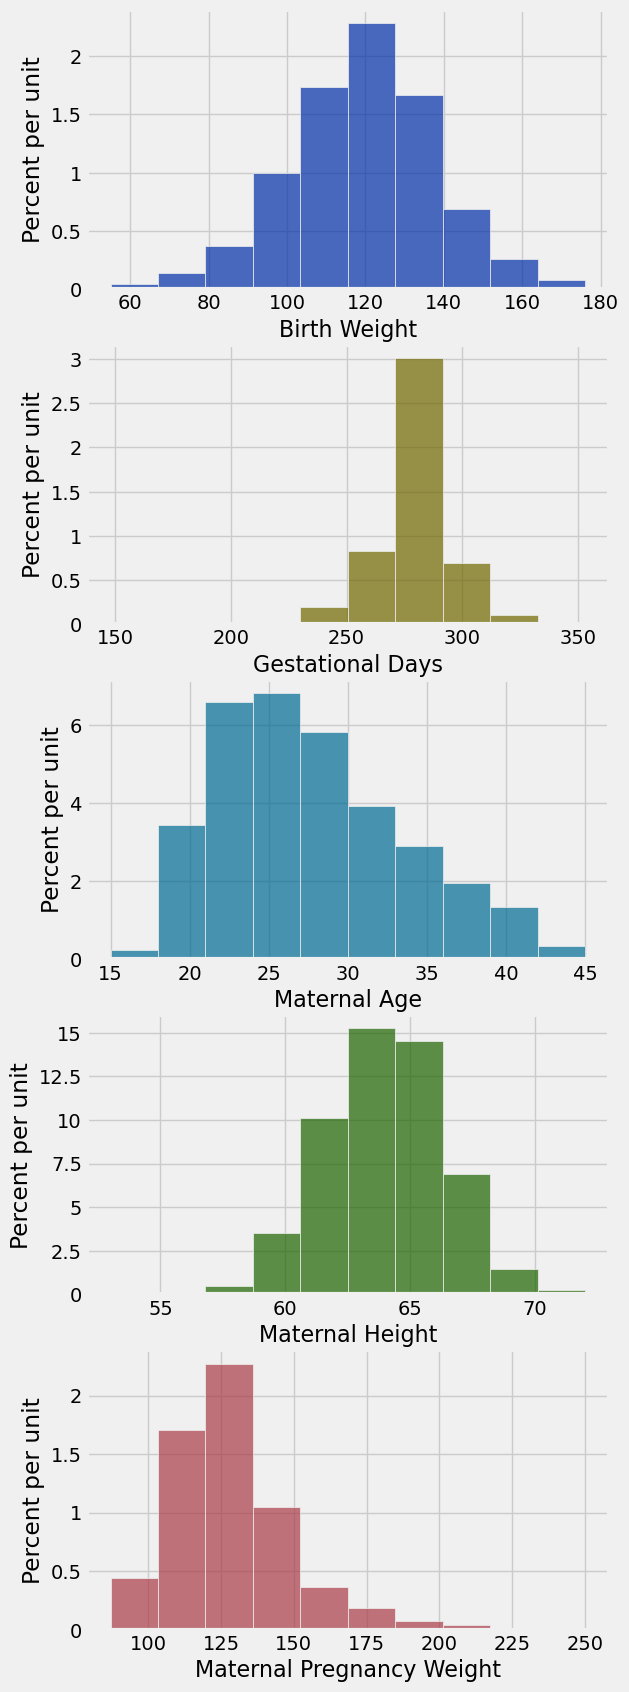

In [27]:
births.hist(overlay = False)

In [28]:
mpw = births.column('Maternal Pregnancy Weight')
mean = np.mean(mpw)
sd = np.std(mpw)
mean, sd

(128.4787052810903, 20.725449704280411)

In [29]:
within_3_SDs = births.where(
    'Maternal Pregnancy Weight', are.between(mean - 3*sd, mean + 3*sd))
within_3_SDs

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight
120,284,27,62,100
113,282,33,64,135
128,279,28,64,115
108,282,23,67,125
136,286,25,62,93
138,244,33,62,178
132,245,23,65,140
120,289,25,62,125
143,299,30,66,136
140,351,27,68,120


In [30]:
# Proportion within 3 SDs of the mean

within_3_SDs.num_rows / births.num_rows

0.9863713798977853

In [31]:
# Chebyshev's bound: 
# This proportion should be at least

1 - 1/3**2

0.8888888888888888

In [32]:
births.labels

('Birth Weight',
 'Gestational Days',
 'Maternal Age',
 'Maternal Height',
 'Maternal Pregnancy Weight')

In [34]:
# See if Chebyshev's bounds work for distributions with various shapes

for feature in births.labels:
    values = births.column(feature)
    mean = np.mean(values)
    sd = np.std(values)
    print()
    print(feature)
    for z in make_array(1, 2, 3, 4, 5):
        chosen = births.where(feature, are.between(mean - z*sd, mean + z*sd))
        proportion = chosen.num_rows / births.num_rows
        percent = round(proportion * 100, 2)
        print('Average plus or minus', z, 'SDs:', percent, '%')


Birth Weight
Average plus or minus 1 SDs: 69.25 %
Average plus or minus 2 SDs: 94.89 %
Average plus or minus 3 SDs: 99.57 %
Average plus or minus 4 SDs: 100.0 %
Average plus or minus 5 SDs: 100.0 %

Gestational Days
Average plus or minus 1 SDs: 79.47 %
Average plus or minus 2 SDs: 93.78 %
Average plus or minus 3 SDs: 98.64 %
Average plus or minus 4 SDs: 99.57 %
Average plus or minus 5 SDs: 99.83 %

Maternal Age
Average plus or minus 1 SDs: 67.46 %
Average plus or minus 2 SDs: 94.89 %
Average plus or minus 3 SDs: 99.91 %
Average plus or minus 4 SDs: 100.0 %
Average plus or minus 5 SDs: 100.0 %

Maternal Height
Average plus or minus 1 SDs: 67.38 %
Average plus or minus 2 SDs: 97.19 %
Average plus or minus 3 SDs: 99.66 %
Average plus or minus 4 SDs: 99.91 %
Average plus or minus 5 SDs: 100.0 %

Maternal Pregnancy Weight
Average plus or minus 1 SDs: 73.85 %
Average plus or minus 2 SDs: 95.06 %
Average plus or minus 3 SDs: 98.64 %
Average plus or minus 4 SDs: 99.49 %
Average plus or minus 

## Standard Units ##

Standardizing the standard deviation tells the number of deviations and direction. 
This is called the z-score and is based on a Normal (symmetric) curve. 
In a Normal distribution, the center is 0 and the Standrad Deviation is 1. 

To standardize, subtract the mean from the data value then divide by the standard deviation.

In [35]:
def standard_units(x):
    """Convert array x to standard units."""
    return (x - np.mean(x)) / np.std(x)

In [36]:
ages = births.column('Maternal Age')
ages

array([27, 33, 28, ..., 30, 21, 38])

In [37]:
# What is happening with this code?
ages_standard_units = standard_units(ages)
ages_standard_units

array([-0.03925456,  0.99249577,  0.13270383, ...,  0.47662061,
       -1.07100488,  1.85228771])

In [38]:
np.mean(ages_standard_units), np.std(ages_standard_units)


(-7.868020072300939e-17, 1.0)

**That's an interesting looking value.**

* What does that notation mean?
* What is it called?
* What does that value approximate?

## Discussion Question 

1. Find the ages that are close to the mean age. 
2. Find the values that are close to the standard deviation of the data set. 


In [39]:
# Show the actual age and the standardized value for the age for each record.

both = Table().with_columns(
    'Age in Years', ages,
    'Age in Standard Units', ages_standard_units
)
both

Age in Years,Age in Standard Units
27,-0.0392546
33,0.992496
28,0.132704
23,-0.727088
25,-0.383171
33,0.992496
23,-0.727088
25,-0.383171
30,0.476621
27,-0.0392546


In [40]:
# COMPLETE: 1. Find the ages that are close to the mean age.
both.where('Age in Standard Units', are.between(-0.5, 0.5)).group('Age in Years')

Age in Years,count
25,75
26,82
27,80
28,64
29,61
30,61


In [46]:
# COMPLETE: 2. Find the values that are close to the standard deviation of the data set.
neg = both.where('Age in Standard Units', are.between(-1.1, -0.9))
pos = both.where('Age in Standard Units', are.between(0.9, 1.1))
neg, pos

(Age in Years | Age in Standard Units
 21           | -1.071
 21           | -1.071
 21           | -1.071
 21           | -1.071
 21           | -1.071
 21           | -1.071
 21           | -1.071
 21           | -1.071
 21           | -1.071
 21           | -1.071
 ... (55 rows omitted),
 Age in Years | Age in Standard Units
 33           | 0.992496
 33           | 0.992496
 33           | 0.992496
 33           | 0.992496
 33           | 0.992496
 33           | 0.992496
 33           | 0.992496
 33           | 0.992496
 33           | 0.992496
 33           | 0.992496
 ... (32 rows omitted))

In [47]:
# Determine the mean and the standard deviation of the data. 

np.mean(ages), np.std(ages)

(27.228279386712096, 5.8153604041908968)

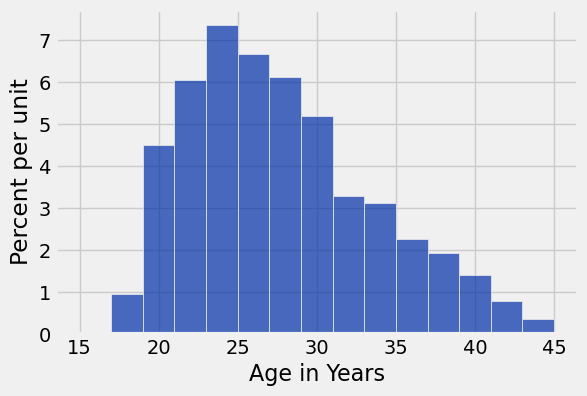

In [48]:
both.hist('Age in Years', bins = np.arange(15, 46, 2))

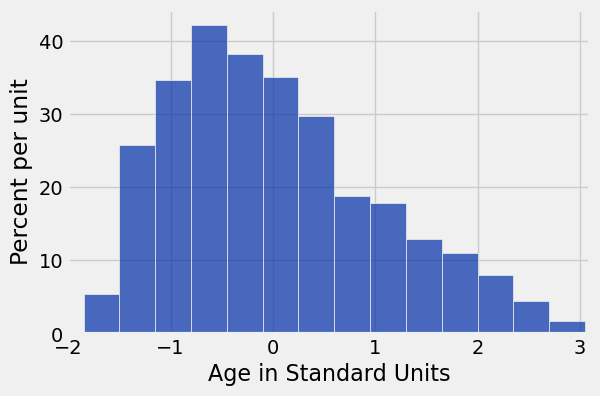

In [49]:
both.hist('Age in Standard Units', bins = np.arange(-2.2, 3.4, 0.35))
plots.xlim(-2, 3.1);

Why do the two histograms look so similar? 

What are the differences?

## The SD and Bell Shaped Curves 

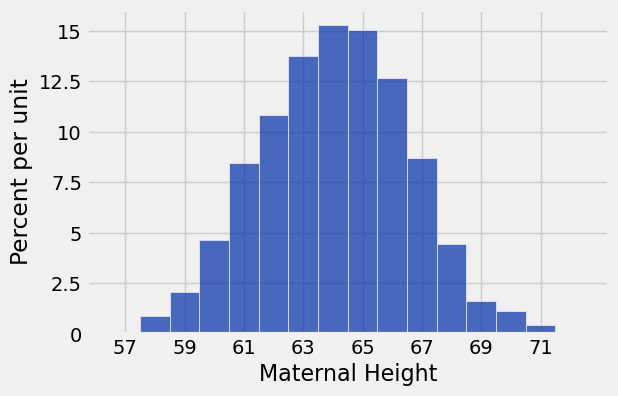

In [50]:
births.hist('Maternal Height', bins = np.arange(56.5, 72.6, 1))
plots.xticks(np.arange(57, 72, 2));

Estimates by eye

The average is approximately: 

Locate the point of inflection on the right (Where the curve begins to change concavity).

The SD is approximately:

In [51]:
heights = births.column('Maternal Height')
np.mean(heights), np.std(heights)

(64.049403747870528, 2.5250254409674375)

How close was your guess to the actual?


In [52]:
# An array of all the maternal heights. 

height = births.column('Maternal Height')
height

array([62, 64, 64, ..., 65, 65, 65])

In [54]:
# Standardize the heights.

height_standard_units = standard_units(height)
height_standard_units

array([-0.81163687, -0.01956564, -0.01956564, ...,  0.37646997,
        0.37646997,  0.37646997])

In [55]:
# Find the mean and standard deviation of the standardized heights. 

np.mean(height_standard_units), np.std(height_standard_units)


(3.0261615662695918e-17, 1.0)

In [56]:
# Create a table that displays both the actual and standardized values. 

both_height = Table().with_columns(
    'Height in Inches', height,
    'Height in Standard Units', height_standard_units
)
both_height

Height in Inches,Height in Standard Units
62,-0.811637
64,-0.0195656
64,-0.0195656
67,1.16854
62,-0.811637
62,-0.811637
65,0.37647
62,-0.811637
66,0.772506
68,1.56458


(-3.1, 3.1)

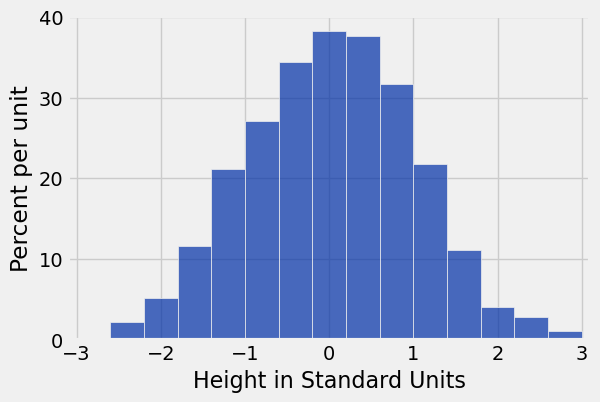

In [57]:
both_height.hist('Height in Standard Units', bins = np.arange(-3, 3.4, 0.4))
plots.xlim(-3.1, 3.1)

How does the histogram of the standardized values compare to the histogram of the actual values?

Why might statiticians want to standardize data?
